# Shadow Analysis

Computes where tree canopies cast shadows given a sun position derived from a UTC datetime.
Loads existing segmentation maps (`.npy`) and overlays shadow predictions on the orthophoto.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from src.config import AREAS, OUTPUT_DIR, TILE_SIZE_M
from src.data_preprocessing import tiles_for_area
from src.shadow import sun_position, estimate_tree_heights, cast_tree_shadows, save_shadow_overlay
from src.shadow.casting import _pixel_size_m

## Parameters

In [2]:
AREA_KEY = "ovgu_bbox"
TILE_IX, TILE_IY = 0, 0
VEGETATION_MODEL = "vari"

# Summer solstice ~1 hour before solar noon (sun is SSE, elevation ~61°)
DATETIME_UTC = dt.datetime(2024, 6, 21, 11, 0, 0, tzinfo=dt.timezone.utc)

## Load segmentation and orthophoto

In [3]:
tiles = tiles_for_area(AREAS[AREA_KEY], TILE_SIZE_M)
tile = next(t for t in tiles if t["ix"] == TILE_IX and t["iy"] == TILE_IY)

stem = f"{AREA_KEY}_tile_{TILE_IX}_{TILE_IY}"
seg_path = OUTPUT_DIR / "segments" / f"{stem}_{VEGETATION_MODEL}_seg.npy"
img_path = OUTPUT_DIR / AREA_KEY / f"{stem}.png"

seg_map = np.load(seg_path)
img = np.array(Image.open(img_path).convert("RGB"))

print(f"seg_map shape: {seg_map.shape}  dtype: {seg_map.dtype}")
print(f"Class distribution: " + "  ".join(f"{v}={int((seg_map==v).sum())} ({(seg_map==v).mean()*100:.1f}%)" for v in [0,1,2,3]))

seg_map shape: (1200, 1200)  dtype: uint8
Class distribution: 0=427109 (29.7%)  1=342721 (23.8%)  2=414286 (28.8%)  3=255884 (17.8%)


## Sun position

In [4]:
lat = (tile["south"] + tile["north"]) / 2
lon = (tile["west"] + tile["east"]) / 2
azimuth, elevation = sun_position(lat, lon, DATETIME_UTC)
shadow_dir = (azimuth + 180) % 360

print(f"Location: {lat:.4f}°N  {lon:.4f}°E")
print(f"Date/time: {DATETIME_UTC.strftime('%Y-%m-%d %H:%M UTC')}")
print(f"Sun azimuth:  {azimuth:.1f}°  (compass, 0°=N)")
print(f"Sun elevation: {elevation:.1f}°")
print(f"Shadow falls toward: {shadow_dir:.1f}°")

Location: 52.1398°N  11.6436°E
Date/time: 2024-06-21 11:00 UTC
Sun azimuth:  172.7°  (compass, 0°=N)
Sun elevation: 61.2°
Shadow falls toward: 352.7°


## Tree height estimation

In [5]:
pixel_size = _pixel_size_m(tile, seg_map.shape)
labeled, heights = estimate_tree_heights(seg_map == 1, pixel_size)

height_values = list(heights.values())
print(f"Pixel size: {pixel_size:.3f} m/px")
print(f"Tree clusters: {len(heights)}")
if height_values:
    print(f"Height range: {min(height_values):.1f} – {max(height_values):.1f} m")
    print(f"Median height: {sorted(height_values)[len(height_values)//2]:.1f} m")

Pixel size: 0.417 m/px
Tree clusters: 202
Height range: 2.4 – 58.1 m
Median height: 7.6 m


## Cast shadows

In [6]:
shadow_mask = cast_tree_shadows(seg_map, tile, DATETIME_UTC)
print(f"Shadow pixels: {shadow_mask.sum()} ({shadow_mask.mean()*100:.1f}% of tile)")

Shadow pixels: 168464 (11.7% of tile)


## Visualise shadow overlay

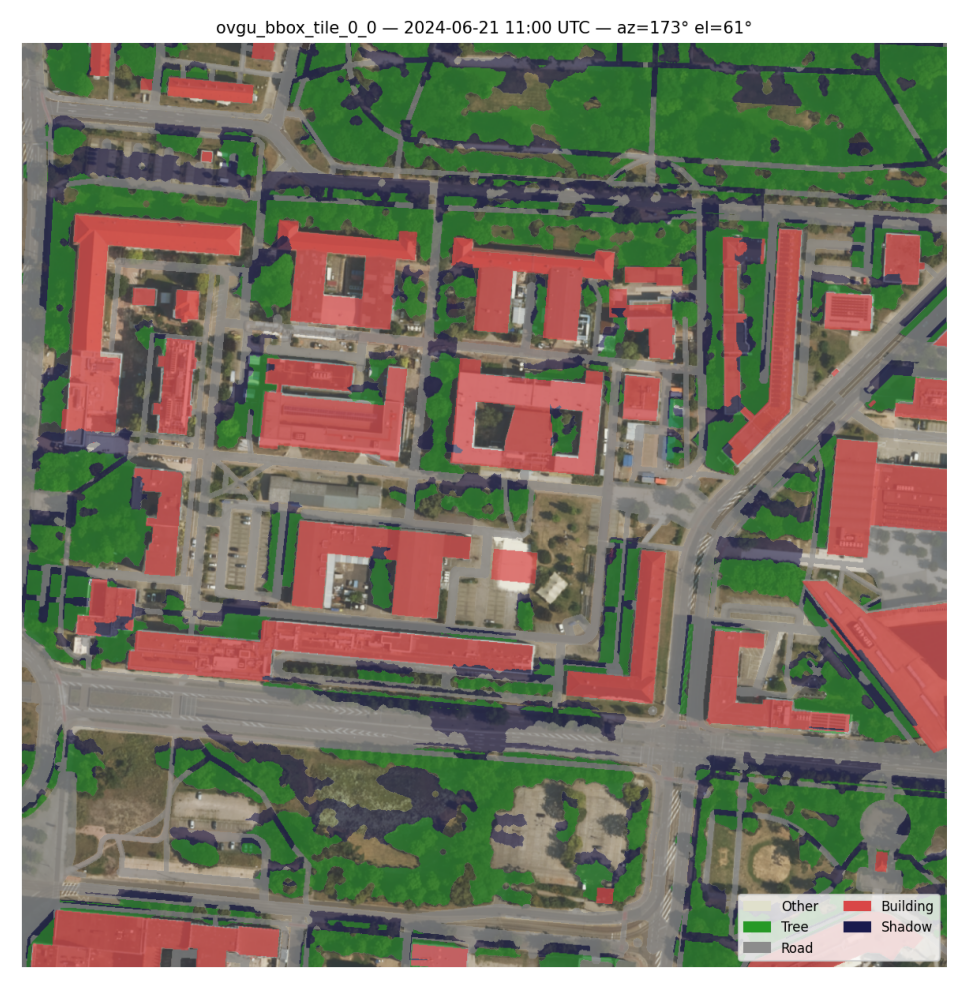

In [7]:
out_path = OUTPUT_DIR / "shadows" / f"{stem}_{VEGETATION_MODEL}_shadow.png"
save_shadow_overlay(
    img, seg_map, shadow_mask, out_path,
    title=f"{stem} — {DATETIME_UTC.strftime('%Y-%m-%d %H:%M UTC')} — az={azimuth:.0f}° el={elevation:.0f}°"
)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(plt.imread(out_path))
ax.axis("off")
plt.tight_layout()
plt.show()

## Sanity checks

In [8]:
# 1. Shadow must not overlap source tree pixels
assert not (shadow_mask & (seg_map == 1)).any(), "Shadow overlaps tree pixels!"
print("✓ No shadow on source tree pixels")

# 2. Per-cluster direction check: each individual shadow should be NORTH of its source
#    tree (negative row offset) for a sun at SSE (~173°).
#    Note: the GLOBAL shadow-vs-tree centroid comparison is misleading because
#    shadows from northern trees get clipped at the image edge, skewing aggregates.
import math
from src.shadow.casting import _shift_mask

pixel_size_check = _pixel_size_m(tile, seg_map.shape)
labeled_check, heights_check = estimate_tree_heights(seg_map == 1, pixel_size_check)
shadow_az_rad_check = math.radians((azimuth + 180) % 360)
elevation_rad_check = math.radians(elevation)

sampled_offsets = []
for k in list(heights_check.keys())[::20]:
    h = heights_check[k]
    crown_radius = h / 1.4
    shadow_length = min(h / math.tan(elevation_rad_check), 5 * crown_radius)
    dx = shadow_length * math.sin(shadow_az_rad_check) / pixel_size_check
    dy = -shadow_length * math.cos(shadow_az_rad_check) / pixel_size_check
    comp = labeled_check == k
    shifted = _shift_mask(comp, int(round(dy)), int(round(dx)))
    shd_r = np.where(shifted)[0]
    if len(shd_r):
        sampled_offsets.append(shd_r.mean() - np.where(comp)[0].mean())

assert all(o < 0 for o in sampled_offsets), f"Expected northward shadow, got: {sampled_offsets}"
print(f"✓ All sampled per-cluster shadows are north of source trees (mean offset {np.mean(sampled_offsets):.1f} px)")

# 3. Night datetime should produce no shadow
night = dt.datetime(2024, 6, 21, 22, 0, 0, tzinfo=dt.timezone.utc)
night_shadow = cast_tree_shadows(seg_map, tile, night)
assert not night_shadow.any(), "Night should produce no shadow!"
print("✓ No shadow at night")

print("\nAll sanity checks passed.")

✓ No shadow on source tree pixels
✓ All sampled per-cluster shadows are north of source trees (mean offset -11.2 px)
✓ No shadow at night

All sanity checks passed.


## Shadow length vs. sun elevation (diurnal cycle)

In [9]:
print(f"{'Hour UTC':>8}  {'Elevation':>9}  {'Azimuth':>8}  {'Shadow %':>9}")
print("-" * 45)
for hour in range(4, 21, 2):
    when = DATETIME_UTC.replace(hour=hour)
    az, el = sun_position(lat, lon, when)
    shd = cast_tree_shadows(seg_map, tile, when)
    print(f"{hour:>8}  {el:>8.1f}°  {az:>7.1f}°  {shd.mean()*100:>8.1f}%")

Hour UTC  Elevation   Azimuth   Shadow %
---------------------------------------------
       4       7.7°     61.2°      13.6%
       6      25.1°     83.4°      14.5%
       8      43.2°    108.6°      13.2%
      10      57.9°    146.2°      12.9%
      12      60.1°    200.9°      11.9%
      14      47.6°    243.5°      13.6%
      16      29.8°    270.7°      12.6%
      18      11.9°    293.1°      11.7%
      20      -3.2°    316.2°       0.0%


## Batch: all tiles

In [10]:
for t in tiles_for_area(AREAS[AREA_KEY], TILE_SIZE_M):
    s = f"{AREA_KEY}_tile_{t['ix']}_{t['iy']}"
    seg_p = OUTPUT_DIR / "segments" / f"{s}_{VEGETATION_MODEL}_seg.npy"
    img_p = OUTPUT_DIR / AREA_KEY / f"{s}.png"
    if not seg_p.exists():
        print(f"[skip] {seg_p.name}")
        continue
    seg = np.load(seg_p)
    im  = np.array(Image.open(img_p).convert("RGB"))
    shd = cast_tree_shadows(seg, t, DATETIME_UTC)
    out = OUTPUT_DIR / "shadows" / f"{s}_{VEGETATION_MODEL}_shadow.png"
    save_shadow_overlay(im, seg, shd, out, title=f"{s} — {DATETIME_UTC.strftime('%Y-%m-%d %H:%M UTC')}")
    print(f"{s}: shadow={shd.mean()*100:.1f}%")

ovgu_bbox_tile_0_0: shadow=11.7%
ovgu_bbox_tile_0_1: shadow=15.7%
ovgu_bbox_tile_1_0: shadow=12.0%
ovgu_bbox_tile_1_1: shadow=10.0%


In [1]:
import geopandas as gpd
from shapely.geometry import box    

In [4]:
trees = gpd.read_file("/Users/kumar/Desktop/Projects.nosync/HiWi1/urban-shadow-analysis/data/orthophotos/segments/ovgu_bbox_tile_3_3_tcd_segformer_trees.fgb")

In [5]:
trees

,tree_id,height_m,crown_radius_m,crown_area_m2,vegetation_model,geometry
0,23,7.600076,5.428626,92.582657,tcd_segformer,"POLYGON ((681502.137 5780415.004, 681502.137 5..."
1,22,10.200970,7.286407,166.792601,tcd_segformer,"POLYGON ((681490.706 5780415.531, 681490.706 5..."
2,26,1.282567,0.916119,2.636658,tcd_segformer,"POLYGON ((681479.275 5780402.626, 681479.275 5..."
3,28,1.925793,1.375566,5.944466,tcd_segformer,"POLYGON ((681487.39 5780395.909, 681487.39 578..."
4,29,3.880596,2.771854,24.137407,tcd_segformer,"POLYGON ((681481.02 5780390.247, 681481.02 578..."
5,25,1.163343,0.830960,2.169251,tcd_segformer,"POLYGON ((681476.395 5780402.889, 681476.395 5..."
6,24,1.423486,1.016776,3.247884,tcd_segformer,"POLYGON ((681471.421 5780407.63, 681471.421 57..."
7,20,4.983140,3.559386,39.801554,tcd_segformer,"POLYGON ((681485.732 5780448.585, 681485.732 5..."
8,19,4.116220,2.940157,27.157579,tcd_segformer,"POLYGON ((681499.52 5780462.807, 681499.52 578..."
9,13,3.245818,2.318441,16.886597,tcd_segformer,"POLYGON ((681504.144 5780480.585, 681504.144 5..."
